In [1]:
import netCDF4 as nc
import matplotlib.pyplot as plt
from matplotlib.colors import from_levels_and_colors
import numpy as np
from matplotlib import animation
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as cols
import matplotlib as mpl
from mpl_toolkits.basemap import Basemap
from matplotlib import ticker, cm
import seaborn as sns

In [2]:
data=nc.Dataset('/home/dell/iHESPdata/B.E.13.BHISTC5.ne120_t12.sehires38.003.sunway.pop.h.nday1.1929-06-01.nc')
lont = data.variables['TLONG'][249,480:1080]
latt = data.variables['TLAT'][249,480:1080]
lont[lont==-1]=np.nan
latt[latt==-1]=np.nan
z = data.variables['z_t'][:]/100

In [3]:
z[32]

482.73672

In [4]:
iceyes = np.load('/home/dell/iHESPdata/weddellsecsep68Stempyes.npy')
iceyes[iceyes>100000]=np.nan
iceno= np.load('/home/dell/iHESPdata/weddellsecsep68Stempno.npy')
iceno[iceno>100000]=np.nan
icediff = iceyes - iceno

saltyes = np.load('/home/dell/iHESPdata/weddellsecsep68Ssaltyes.npy')
saltyes[saltyes>100000]=np.nan
saltno = np.load('/home/dell/iHESPdata/weddellsecsep68Ssaltno.npy')
saltno[saltno>100000]=np.nan
saltdiff = saltyes - saltno

PDyes = np.load('/home/dell/iHESPdata/weddellsecsep68SPDyes.npy')
PDyes[PDyes>100000]=np.nan
PDno = np.load('/home/dell/iHESPdata/weddellsecsep68SPDno.npy')
PDno[PDno>100000]=np.nan
PDyes = (PDyes-1)*1000
PDno = (PDno-1)*1000

In [5]:
VVVno = np.load('/home/dell/iHESPplot/sectionplot/VVVno.npy')
VVVyes = np.load('/home/dell/iHESPplot/sectionplot/VVVyes.npy')
VVVdif = np.load('/home/dell/iHESPplot/sectionplot/VVVdif.npy')

In [6]:
iceyes.shape

(62, 600)

In [7]:
X, Y = np.meshgrid(lont, z)

In [8]:
Y.shape

(62, 600)

In [9]:
import pop_tools
depth=1000.
tmp = pop_tools.eos(salt=saltno,temp=iceno,return_coefs=False,depth=depth)
sigma1 = tmp - 1000.

tmp = pop_tools.eos(salt=saltyes,temp=iceyes,return_coefs=False,depth=depth)
sigma1yes = tmp - 1000.

sigmadiff = sigma1yes - sigma1

/home/dell/anaconda3/envs/Xiliangdiao/lib/python3.6/site-packages/pop_tools/eos.py:136: RuntimeWarning: invalid value encountered in _compute_eos
  RHO = _compute_eos(salt, temp, pressure)


findfont: Font family ['Cambria'] not found. Falling back to DejaVu Sans.


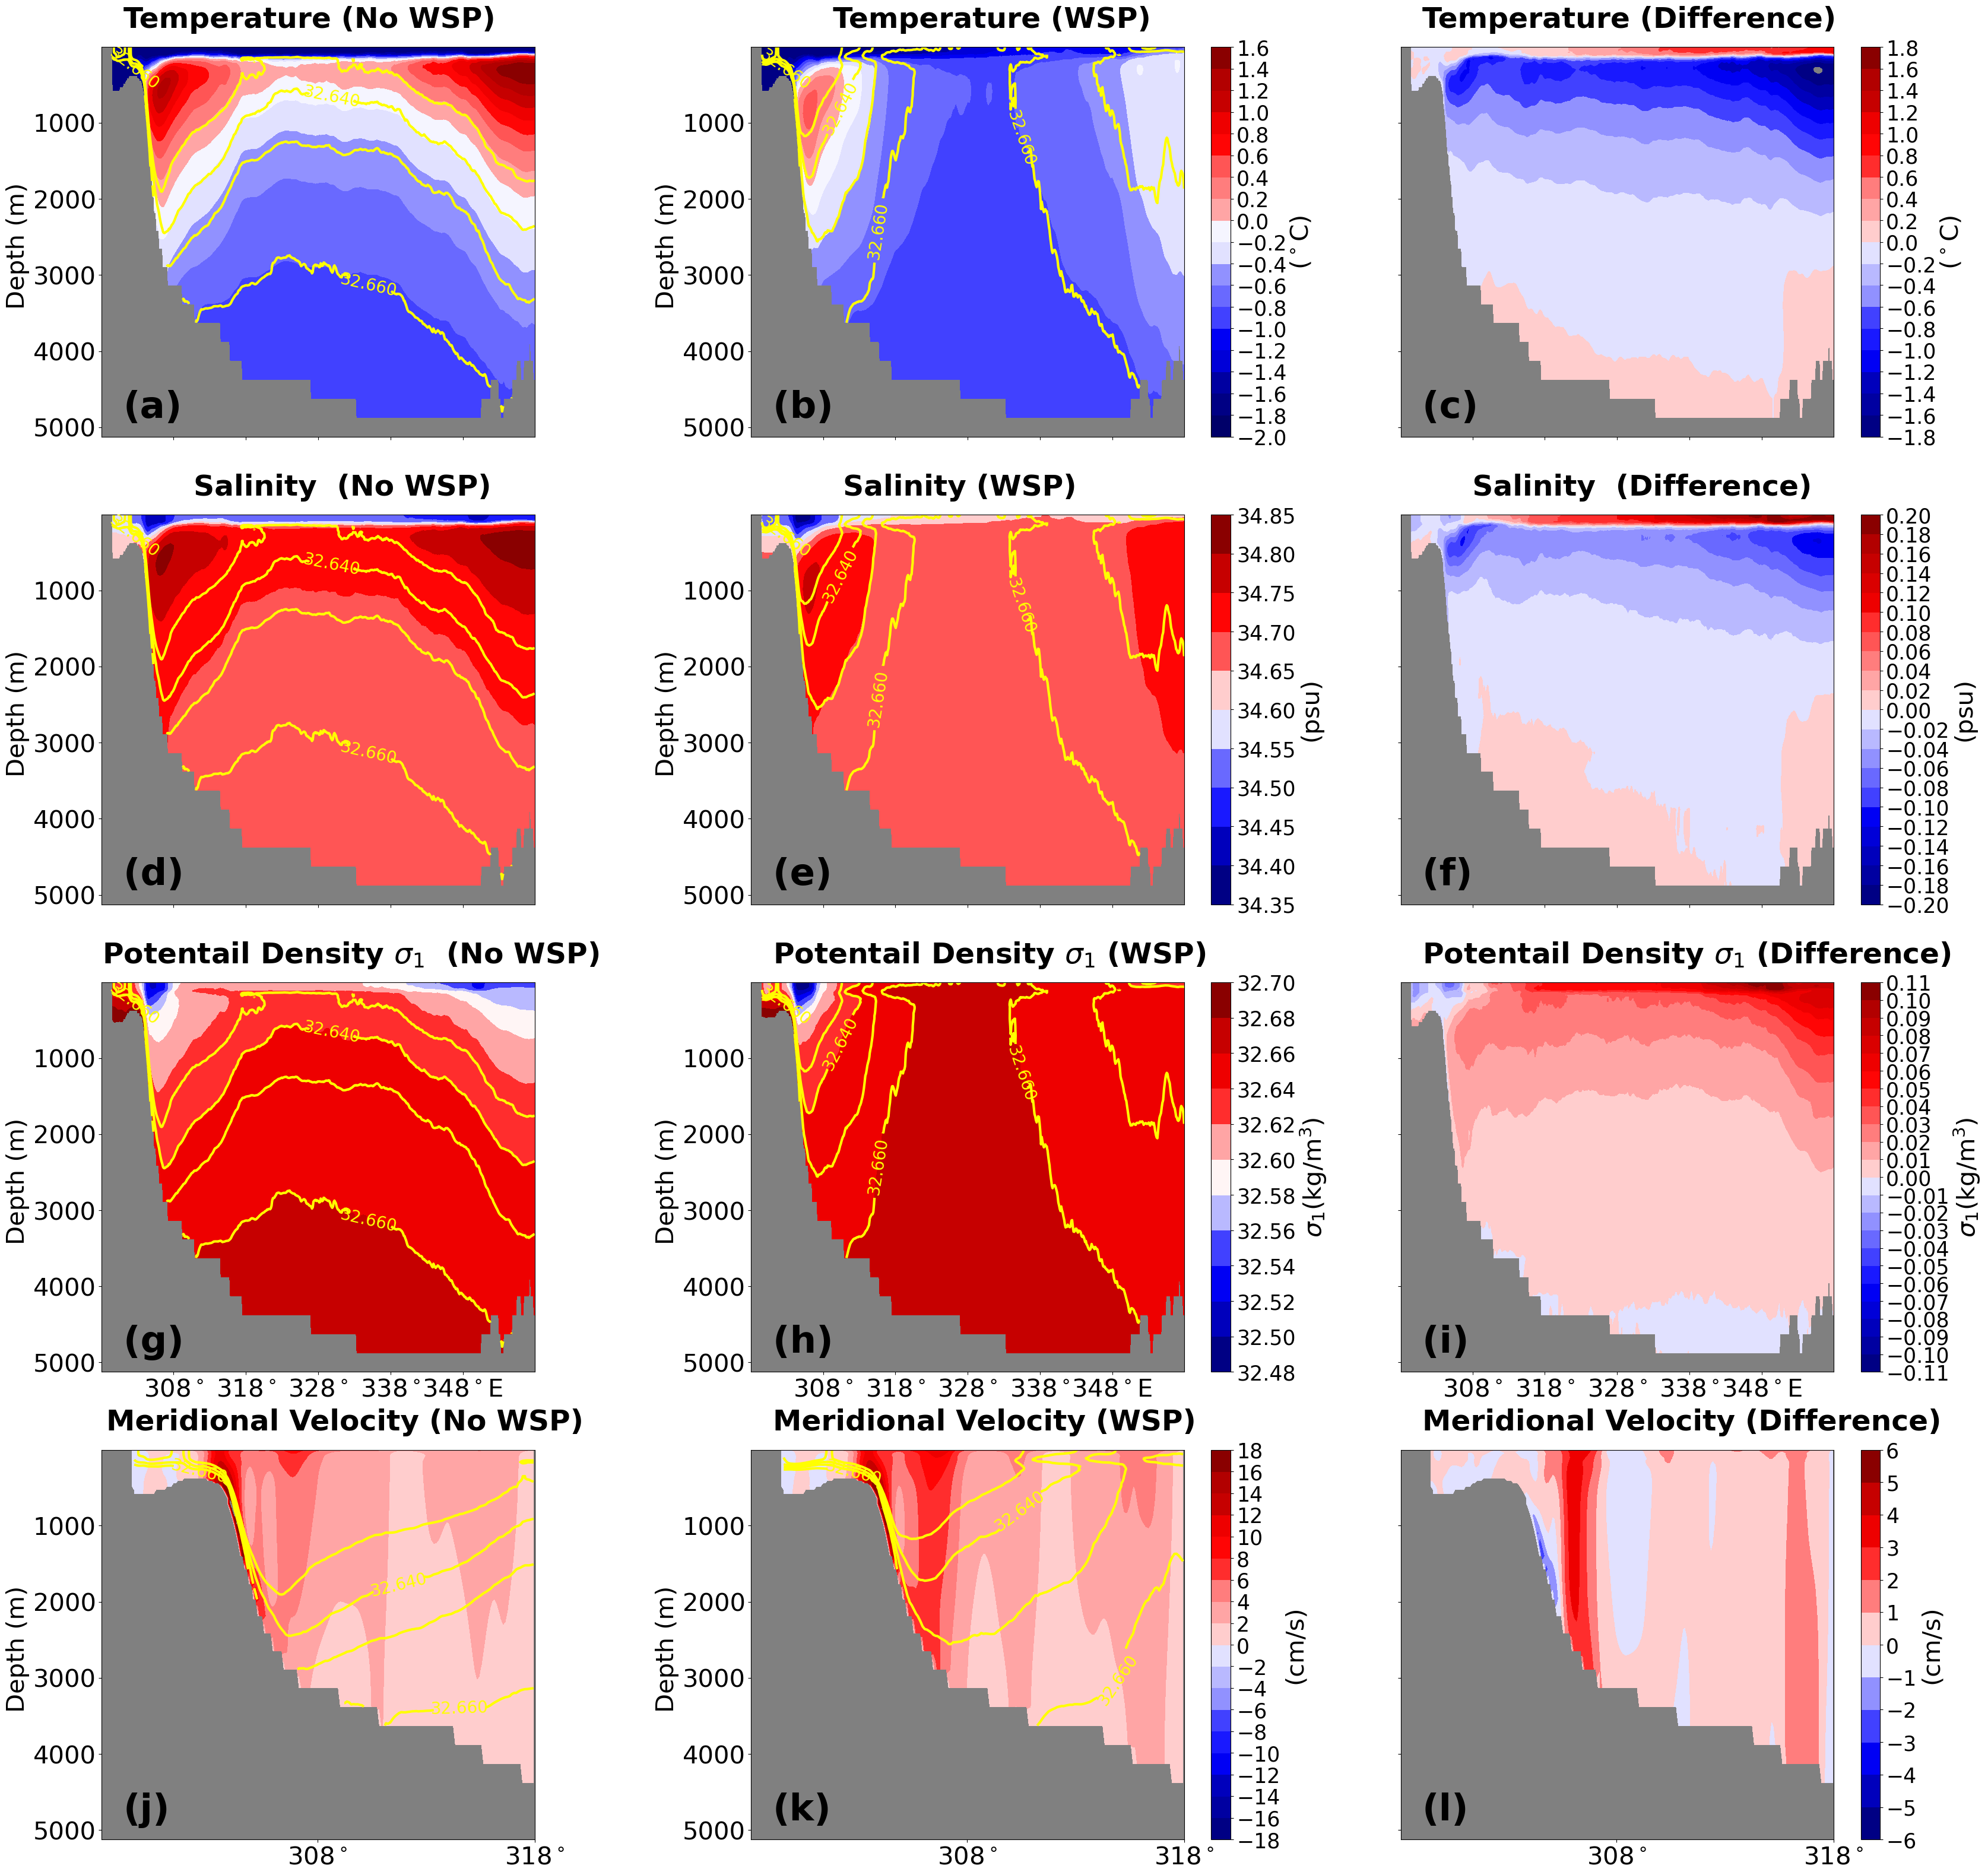

In [10]:
#################################################################
nice_cmap=plt.get_cmap('seismic')
#lev_cmap = nice_cmap([250,240,230,220,210,190,180,170,150,130,120,110,100,90,80,70,60,50,40,30,20,10])
lev_cmap = nice_cmap([10,20,30,40,50,60,70,80,90,100,110,120,125,140,150,160,170,180,190,200,210,220,230,240,250])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [-2,-1.8,-1.6,-1.4,-1.2,-1,-0.8,-0.6,-0.4,-0.2,0,0.2,0.4,0.6,0.8,1,1.2,1.4,1.6]
#nice_levels = [85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#################################################################

fig = plt.figure(figsize=(40,40), dpi=100)
my_font = {'fontname':'Cambria', 'size':'30'}
################################################################
manual_positions = [(30, 300), (30, 600), (30, 800)]
################################################################
t = np.arange(3,249,1)
ax1 = plt.subplot(4, 3, 1)

CP = ax1.contourf(X[:59,:],Y[:59,:],iceno[:59,:],cmap = new_cmap,norm =norm,levels = nice_levels)
CS = ax1.contour(X[:59,:],Y[:59,:],sigma1[:59,:],[32.63,32.64,32.65,32.66],colors='yellow',linewidths=3)
plt.gca().invert_yaxis()
plt.xticks(np.arange(308,358,10), ['','','','',''],**my_font)
ax1.set_facecolor("grey")
CS.clabel([32.64,32.66], inline=True, fontsize=20)
plt.yticks(np.arange(1000,6000,1000), ['1000','2000','3000','4000','5000'],**my_font,color='k')
plt.ylabel('Depth (m) ',**my_font,color='k')
#ax=[axs[2, 1]], location='left'
cbar =plt.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=25) 
cbar.set_label('($^\circ$C)', **my_font)
cbar.remove()
ax1.text(0.05, 1.05, 'Temperature (No WSP)', transform=ax1.transAxes,size=35, weight='bold', color='black')
ax1.text(0.05, 0.05, '(a)', transform=ax1.transAxes,size=45, weight='bold', color='black')


ax1 = plt.subplot(4, 3, 2)

CP = ax1.contourf(X[:59,:],Y[:59,:],iceyes[:59,:],cmap = new_cmap,norm =norm,levels = nice_levels)
CS = ax1.contour(X[:59,:],Y[:59,:],sigma1yes[:59,:],[32.63,32.64,32.65,32.66],colors='yellow',linewidths=3)
plt.gca().invert_yaxis()
plt.xticks(np.arange(308,358,10), ['','','','',''],**my_font)
ax1.set_facecolor("grey")
CS.clabel([32.64,32.66], inline=True, fontsize=20)
plt.yticks(np.arange(1000,6000,1000), ['1000','2000','3000','4000','5000'],**my_font,color='k')
plt.ylabel('Depth (m) ',**my_font,color='k')
cbar =plt.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=25) 
cbar.set_label('($^\circ$C)', **my_font)
#cbar.remove()
ax1.text(0.05, 1.05, '      Temperature (WSP)', transform=ax1.transAxes,size=35, weight='bold', color='black')
ax1.text(0.05, 0.05, '(b) ', transform=ax1.transAxes,size=45, weight='bold', color='black')
#################################################################
nice_cmap=plt.get_cmap('seismic')
#lev_cmap = nice_cmap([250,240,230,220,210,190,180,170,150,130,120,110,100,90,80,70,60,50,40,30,20,10])
lev_cmap = nice_cmap([20,30,40,50,60,70,80,90,100,110,120,125,140,150,160,170,180,190,200,210,220,230,240,250])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [-1.8,-1.6,-1.4,-1.2,-1,-0.8,-0.6,-0.4,-0.2,0,0.2,0.4,0.6,0.8,1,1.2,1.4,1.6,1.8]
#nice_levels = [85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#################################################################
ax1 = plt.subplot(4, 3, 3)

CP = ax1.contourf(X[:59,:],Y[:59,:],icediff[:59,:],cmap = new_cmap,norm =norm,levels = nice_levels)
plt.gca().invert_yaxis()
plt.xticks(np.arange(308,358,10), ['','','','',''],**my_font)
ax1.set_facecolor("grey")
plt.yticks(np.arange(1000,6000,1000), ['','','','',''],**my_font,color='k')
cbar =plt.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=25) 
cbar.set_label('($^\circ$C)', **my_font)
ax1.text(0.05, 1.05, 'Temperature (Difference)', transform=ax1.transAxes,size=35, weight='bold', color='black')
ax1.text(0.05, 0.05, '(c) ', transform=ax1.transAxes,size=45, weight='bold', color='black')
#################################################################
nice_cmap=plt.get_cmap('seismic')
#lev_cmap = nice_cmap([250,240,230,220,210,190,180,170,150,130,120,110,100,90,80,70,60,50,40,30,20,10])
lev_cmap = nice_cmap([20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240,250])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [34.35,34.4,34.45,34.5,34.55,34.6,34.65,34.7,34.75,34.8,34.85]
#nice_levels = [85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#################################################################

ax1 = plt.subplot(4, 3, 4)

CP = ax1.contourf(X[:59,:],Y[:59,:],saltno[:59,:],cmap = new_cmap,norm =norm,levels = nice_levels)
CS = ax1.contour(X[:59,:],Y[:59,:],sigma1[:59,:],[32.63,32.64,32.65,32.66],colors='yellow',linewidths=3)
plt.gca().invert_yaxis()
plt.xticks(np.arange(308,358,10), ['','','','',''],**my_font)
ax1.set_facecolor("grey")
CS.clabel([32.64,32.66], inline=True, fontsize=20)
plt.yticks(np.arange(1000,6000,1000), ['1000','2000','3000','4000','5000'],**my_font,color='k')
plt.ylabel('Depth (m) ',**my_font,color='k')
cbar =plt.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=25) 
cbar.set_label('(psu)', **my_font)
cbar.remove()
ax1.text(0.05, 1.05, '       Salinity  (No WSP)', transform=ax1.transAxes,size=35, weight='bold', color='black')
ax1.text(0.05, 0.05, '(d) ', transform=ax1.transAxes,size=45, weight='bold', color='black')


ax1 = plt.subplot(4, 3, 5)

CP = ax1.contourf(X[:59,:],Y[:59,:],saltyes[:59,:],cmap = new_cmap,norm =norm,levels = nice_levels)
CS = ax1.contour(X[:59,:],Y[:59,:],sigma1yes[:59,:],[32.63,32.64,32.65,32.66],colors='yellow',linewidths=3)
plt.gca().invert_yaxis()
plt.xticks(np.arange(308,358,10), ['','','','',''],**my_font)
ax1.set_facecolor("grey")
CS.clabel([32.64,32.66], inline=True, fontsize=20)
plt.yticks(np.arange(1000,6000,1000), ['1000','2000','3000','4000','5000'],**my_font,color='k')
plt.ylabel('Depth (m) ',**my_font,color='k')
cbar =plt.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=25) 
cbar.set_label('(psu)', **my_font)
#cbar.remove()

ax1.text(0.05, 1.05, '       Salinity (WSP)', transform=ax1.transAxes,size=35, weight='bold', color='black')
ax1.text(0.05, 0.05, '(e) ', transform=ax1.transAxes,size=45, weight='bold', color='black')
#################################################################
nice_cmap=plt.get_cmap('seismic')
#lev_cmap = nice_cmap([250,240,230,220,210,190,180,170,150,130,120,110,100,90,80,70,60,50,40,30,20,10])
lev_cmap = nice_cmap([20,30,40,50,60,70,80,90,100,110,120,125,140,150,160,170,180,190,200,210,220,230,240,250])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [-0.2,-0.18,-0.16,-0.14,-0.12,-0.1,-0.08,-0.06,-0.04,-0.02,0,0.02,0.04,0.06,0.08,0.1,0.12,0.14,0.16,0.18,0.2]
#nice_levels = [85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#################################################################
ax1 = plt.subplot(4, 3, 6)

CP = ax1.contourf(X[:59,:],Y[:59,:],saltdiff[:59,:],cmap = new_cmap,norm =norm,levels = nice_levels)
plt.gca().invert_yaxis()
plt.xticks(np.arange(308,358,10), ['','','','',''],**my_font)
ax1.set_facecolor("grey")
plt.yticks(np.arange(1000,6000,1000), ['','','','',''],**my_font,color='k')
cbar =plt.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=25) 
cbar.set_label('(psu)', **my_font)
ax1.text(0.05, 1.05, '     Salinity  (Difference)', transform=ax1.transAxes,size=35, weight='bold', color='black')
ax1.text(0.05, 0.05, '(f) ', transform=ax1.transAxes,size=45, weight='bold', color='black')
#################################################################
nice_cmap=plt.get_cmap('seismic')
#lev_cmap = nice_cmap([250,240,230,220,210,190,180,170,150,130,120,110,100,90,80,70,60,50,40,30,20,10])
lev_cmap = nice_cmap([20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240,250])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [32.48,32.5,32.52,32.54,32.56,32.58,32.6,32.62,32.64,32.66,32.68,32.7]
#nice_levels = [85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#################################################################

ax1 = plt.subplot(4, 3, 7)

CP = ax1.contourf(X[:59,:],Y[:59,:],sigma1[:59,:],cmap = new_cmap,norm =norm,levels = nice_levels)
CS = ax1.contour(X[:59,:],Y[:59,:],sigma1[:59,:],[32.63,32.64,32.65,32.66],colors='yellow',linewidths=3)
plt.gca().invert_yaxis()
plt.xticks(np.arange(308,358,10), ['308$^\circ$','318$^\circ$','328$^\circ$','338$^\circ$','348$^\circ$E'],**my_font)
ax1.set_facecolor("grey")
CS.clabel([32.64,32.66], inline=True, fontsize=20)
plt.yticks(np.arange(1000,6000,1000), ['1000','2000','3000','4000','5000'],**my_font,color='k')
plt.ylabel('Depth (m) ',**my_font,color='k')
cbar =plt.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=25) 
cbar.set_label('$\sigma$$_1$(kg/m$^3$)', **my_font)
cbar.remove()
ax1.text(0.001, 1.05, 'Potentail Density $\sigma$$_1$  (No WSP)', transform=ax1.transAxes,size=35, weight='bold', color='black')
ax1.text(0.05, 0.05, '(g) ', transform=ax1.transAxes,size=45, weight='bold', color='black')


ax1 = plt.subplot(4, 3, 8)

CP = ax1.contourf(X[:59,:],Y[:59,:],sigma1yes[:59,:],cmap = new_cmap,norm =norm,levels = nice_levels)
CS = ax1.contour(X[:59,:],Y[:59,:],sigma1yes[:59,:],[32.63,32.64,32.65,32.66],colors='yellow',linewidths=3)
plt.gca().invert_yaxis()
plt.xticks(np.arange(308,358,10), ['308$^\circ$','318$^\circ$','328$^\circ$','338$^\circ$','348$^\circ$E'],**my_font)
ax1.set_facecolor("grey")
CS.clabel([32.64,32.66], inline=True, fontsize=20)
plt.yticks(np.arange(1000,6000,1000), ['1000','2000','3000','4000','5000'],**my_font,color='k')
plt.ylabel('Depth (m) ',**my_font,color='k')
cbar =plt.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=25) 
cbar.set_label('$\sigma$$_1$(kg/m$^3$)', **my_font)

#cbar.remove()
ax1.text(0.05, 1.05, 'Potentail Density $\sigma$$_1$ (WSP)', transform=ax1.transAxes,size=35, weight='bold', color='black')
ax1.text(0.05, 0.05, '(h) ', transform=ax1.transAxes,size=45, weight='bold', color='black')

#################################################################
nice_cmap=plt.get_cmap('seismic')
#lev_cmap = nice_cmap([250,240,230,220,210,190,180,170,150,130,120,110,100,90,80,70,60,50,40,30,20,10])
lev_cmap = nice_cmap([20,30,40,50,60,70,80,90,100,110,120,125,140,150,160,170,180,190,200,210,220,230,240,250])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [-0.11,-0.1,-0.09,-0.08,-0.07,-0.06,-0.05,-0.04,-0.03,-0.02,-0.01,0,0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,0.1,0.11]
#nice_levels = [85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#################################################################
ax1 = plt.subplot(4, 3, 9)

CP = ax1.contourf(X[:59,:],Y[:59,:],sigmadiff[:59,:],cmap = new_cmap,norm =norm,levels = nice_levels)

plt.gca().invert_yaxis()
plt.xticks(np.arange(308,358,10), ['308$^\circ$','318$^\circ$','328$^\circ$','338$^\circ$','348$^\circ$E'],**my_font)
ax1.set_facecolor("grey")

plt.yticks(np.arange(1000,6000,1000), ['','','','',''],**my_font,color='k')
cbar =plt.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=25) 
cbar.set_label('$\sigma$$_1$(kg/m$^3$)', **my_font)
ax1.text(0.05, 1.05, 'Potentail Density $\sigma$$_1$ (Difference)', transform=ax1.transAxes,size=35, weight='bold', color='black')
ax1.text(0.05, 0.05, '(i) ', transform=ax1.transAxes,size=45, weight='bold', color='black')

#################################################################
nice_cmap=plt.get_cmap('seismic')
#lev_cmap = nice_cmap([250,240,230,220,210,190,180,170,150,130,120,110,100,90,80,70,60,50,40,30,20,10])
lev_cmap = nice_cmap([20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240,250])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [-18,-16,-14,-12,-10,-8,-6,-4,-2,0,2,4,6,8,10,12,14,16,18]
#nice_levels = [85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#################################################################
ax1 = plt.subplot(4, 3, 10)

CP = ax1.contourf(X[:59,:200],Y[:59,:200],VVVno[:59,:200],cmap = new_cmap,norm =norm,levels = nice_levels)
CS = ax1.contour(X[:59,:200],Y[:59,:200],sigma1[:59,:200],[32.63,32.64,32.65,32.66],colors='yellow',linewidths=3)
plt.gca().invert_yaxis()
plt.xticks(np.arange(308,328,10), ['308$^\circ$','318$^\circ$'],**my_font)
ax1.set_facecolor("grey")
plt.yticks(np.arange(1000,6000,1000), ['1000','2000','3000','4000','5000'],**my_font,color='k')
plt.ylabel('Depth (m) ',**my_font,color='k')
CS.clabel([32.64,32.66], inline=True, fontsize=20)
cbar =plt.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=25) 
cbar.set_label('(cm/s)', **my_font)
cbar.remove()
ax1.text(0.01, 1.05, 'Meridional Velocity (No WSP)', transform=ax1.transAxes,size=35, weight='bold', color='black')
ax1.text(0.05, 0.05, '(j)', transform=ax1.transAxes,size=45, weight='bold', color='black')


ax1 = plt.subplot(4, 3, 11)

CP = ax1.contourf(X[:59,:200],Y[:59,:200],VVVyes[:59,:200],cmap = new_cmap,norm =norm,levels = nice_levels)
CS = ax1.contour(X[:59,:200],Y[:59,:200],sigma1yes[:59,:200],[32.63,32.64,32.65,32.66],colors='yellow',linewidths=3)
plt.gca().invert_yaxis()
plt.xticks(np.arange(308,328,10), ['308$^\circ$','318$^\circ$'],**my_font)
ax1.set_facecolor("grey")
plt.yticks(np.arange(1000,6000,1000), ['1000','2000','3000','4000','5000'],**my_font,color='k')
plt.ylabel('Depth (m) ',**my_font,color='k')
CS.clabel([32.64,32.66], inline=True, fontsize=20)
cbar =plt.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=25) 
cbar.set_label('(cm/s)', **my_font)
#cbar.remove()
ax1.text(0.05, 1.05, 'Meridional Velocity (WSP)', transform=ax1.transAxes,size=35, weight='bold', color='black')
ax1.text(0.05, 0.05, '(k)', transform=ax1.transAxes,size=45, weight='bold', color='black')

#################################################################
nice_cmap=plt.get_cmap('seismic')
#lev_cmap = nice_cmap([250,240,230,220,210,190,180,170,150,130,120,110,100,90,80,70,60,50,40,30,20,10])
lev_cmap = nice_cmap([20,30,40,50,60,70,80,90,100,110,120,130,140,150,160,170,180,190,200,210,220,230,240,250])
new_cmap = cols.ListedColormap(lev_cmap,"seismic")
nice_levels = [-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6]
#nice_levels = [85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100]
norm = mpl.colors.BoundaryNorm(nice_levels, new_cmap.N)
#################################################################


ax1 = plt.subplot(4, 3, 12)

CP = ax1.contourf(X[:59,:200],Y[:59,:200],VVVdif[:59,:200],cmap = new_cmap,norm =norm,levels = nice_levels)
plt.gca().invert_yaxis()
plt.xticks(np.arange(308,328,10), ['308$^\circ$','318$^\circ$'],**my_font)
ax1.set_facecolor("grey")
plt.yticks(np.arange(1000,6000,1000), ['','','','',''],**my_font,color='k')
cbar =plt.colorbar(CP,ticks = nice_levels)
cbar.ax.tick_params(labelsize=25) 
cbar.set_label('(cm/s)', **my_font)
ax1.text(0.05, 1.05, 'Meridional Velocity (Difference)', transform=ax1.transAxes,size=35, weight='bold', color='black')
ax1.text(0.05, 0.05, '(l)', transform=ax1.transAxes,size=45, weight='bold', color='black')
plt.savefig("Fig2.png",bbox_inches='tight')
